In [28]:
# =========================
# Imports
# =========================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve
from xgboost import XGBRegressor
import matplotlib.pyplot as plt




# =========================
# Load data
# =========================
df = pd.read_csv("../data/housing_clean.csv")

# =========================
# Feature Engineering
# =========================

# Binary features
df["was_renovated"] = (df["yr_renovated"] > 0).astype(int)
df["has_basement"] = (df["sqft_basement"] > 0).astype(int)

# Age features
df["house_age"] = df["year"] - df["yr_built"]
df["log_age"] = np.log1p(df["house_age"])

# Log transform skewed features
df["sqft_living"] = np.log1p(df["sqft_living"])
df["sqft_lot"] = np.log1p(df["sqft_lot"])

# =========================
# Structural features
# =========================

# Total usable space
df["total_sqft"] = df["sqft_living"] + df["sqft_basement"]

# Density (safe division)
df["sqft_density"] = df["sqft_living"] / np.maximum(df["sqft_lot"], 1e-6)

# =========================
# Interaction features
# =========================

df["living_per_bedroom"] = df["sqft_living"] / np.maximum(df["bedrooms"], 1)
df["bath_per_bedroom"] = df["bathrooms"] / np.maximum(df["bedrooms"], 1)

# NEW: spatial interaction
df["lat_long_interaction"] = df["lat"] * df["long"]

# =========================
# Remove redundant / noisy features
# =========================
df = df.drop(
    columns=["id", "yr_renovated", "sqft_above", "day", "yr_built"],
    errors="ignore"
)

# =========================
# Clean numeric issues
# =========================
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

# =========================
# Split data
# =========================
X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# Zipcode Mean Encoding (NO LEAKAGE)
# =========================
train_df = X_train.copy()
train_df["price"] = y_train

zipcode_mean = train_df.groupby("zipcode")["price"].mean()

# Apply encoding
X_train["zipcode_mean"] = X_train["zipcode"].map(zipcode_mean)
X_test["zipcode_mean"] = X_test["zipcode"].map(zipcode_mean)

# Handle unseen zipcodes
X_test["zipcode_mean"] = X_test["zipcode_mean"].fillna(zipcode_mean.mean())

# Drop original zipcode
X_train = X_train.drop("zipcode", axis=1)
X_test = X_test.drop("zipcode", axis=1)

# =========================
# Convert booleans to int
# =========================
bool_cols = X_train.select_dtypes(include="bool").columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

# =========================
# Final sanity check
# =========================
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("NaNs:", X_train.isnull().sum().sum(), X_test.isnull().sum().sum())
print("Infs:", np.isinf(X_train).sum().sum(), np.isinf(X_test).sum().sum())

Train shape: (17290, 27)
Test shape: (4323, 27)
NaNs: 0 0
Infs: 0 0


c:\Users\Asus\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [40]:
print(X_train)

       bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
6325          3       1.75     7.484930  9.480062     1.0           0     0   
13473         2       1.00     6.908755  8.216358     1.0           0     0   
17614         3       1.00     6.985642  8.920923     1.5           0     0   
16970         3       2.25     7.645398  8.922792     1.0           0     0   
20868         2       2.50     7.462789  7.272398     2.0           0     0   
...         ...        ...          ...       ...     ...         ...   ...   
11964         3       1.50     6.908755  8.841448     1.0           0     0   
21575         3       2.50     8.035279  8.517793     2.0           0     0   
5390          3       2.50     7.659643  8.472405     2.0           0     0   
860           1       0.75     5.942799  9.615872     1.0           0     0   
15795         4       2.50     8.049108  8.699515     2.0           0     0   

       condition  grade  sqft_basement  ...  was_re

In [30]:
print(np.isinf(X_train).sum().sum())
print(np.isnan(X_train).sum().sum())

0
0


In [81]:

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split= 2,
    random_state=42
)

model.fit(X_train, y_train)

print("Train R²:", model.score(X_train, y_train))
print("Test R²:", model.score(X_test, y_test))

Train R²: 0.9835010520916022
Test R²: 0.8710973011591102


In [82]:
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
print(feat_imp.sort_values(ascending=False).head(10))

grade                   0.306857
sqft_living             0.267117
zipcode_mean            0.198311
long                    0.036528
waterfront              0.029385
view                    0.021313
lat                     0.018986
sqft_living15           0.017647
lat_long_interaction    0.016455
bathrooms               0.009650
dtype: float64


Tuning with Grid search "Engine" 

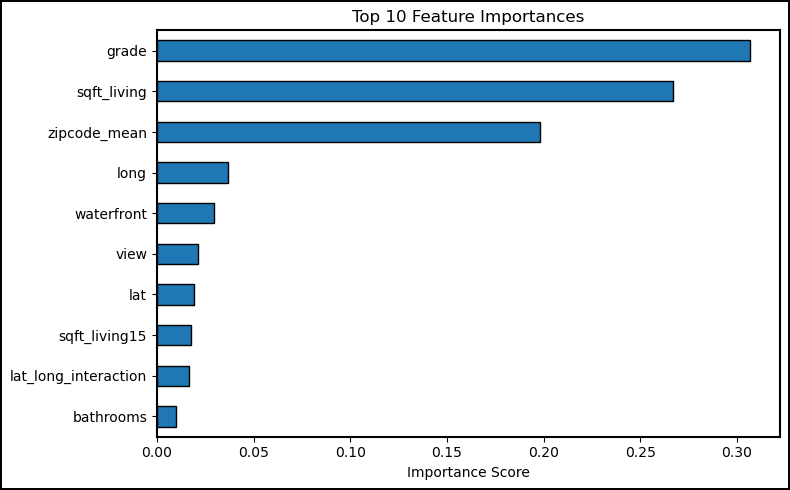

In [84]:
import matplotlib.pyplot as plt

# Get top 10 features
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
top_features = feat_imp.sort_values(ascending=False).head(10)

# Plot
fig, ax = plt.subplots(figsize=(8,5))

top_features.sort_values().plot(
    kind='barh',
    edgecolor='black',
    ax=ax
)

# Add black border around entire plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

# Optional: also add border around figure (outer frame)
fig.patch.set_edgecolor('black')
fig.patch.set_linewidth(1.5)

ax.set_title("Top 10 Feature Importances")
ax.set_xlabel("Importance Score")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [ ]:
"""""
param_grid = {
    'n_estimators': [200],
    'max_depth': [20,30],
    'min_samples_split': [2],
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.8739426247865394


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 71700.61027673392
RMSE: 139596.15400075115
R²: 0.8710973011591102


In [34]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("MAPE:", mape, "%")

MAPE: 13.013177075363544 %


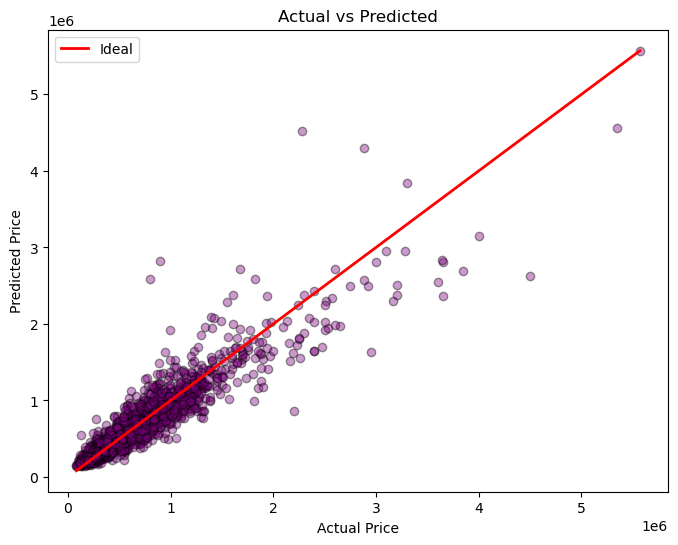

In [92]:

plt.figure(figsize=(8,6))

# Scatter plot (change color here)
plt.scatter(y_test, y_pred, alpha=0.4, color='purple', edgecolor='black')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Ideal')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.legend()
plt.show()

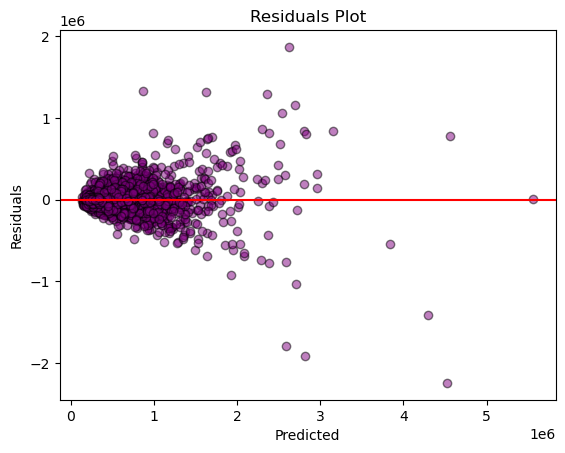

In [36]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.5,color='purple', edgecolor='black')
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals Plot")
plt.show()

Trying Regrressors: 

In [65]:
from xgboost import XGBRegressor

XGBRegressor(
    n_estimators= 700,
    max_depth= 5,
    learning_rate= 0.05,
    subsample=0.8,
    colsample_bytree=0.6,
    reg_lambda= 1.5,
    random_state=42,
    objective='reg:squarederror',
    reg_alpha=1 ,
    n_jobs=-1 ,
    
)


model.fit(X_train, y_train)

print("Train R²:", model.score(X_train, y_train))
print("Test R²:", model.score(X_test, y_test))

Train R²: 0.9263676156418493
Test R²: 0.8823447647291862


In [77]:

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV


xgb = XGBRegressor(
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1 
)

param_grid = {
    "n_estimators": [700],
    "max_depth": [5],
    "learning_rate": [0.01,0.05],
    "subsample": [0.8],
    "colsample_bytree": [0.6],
    "reg_lambda" :[1.5],
    "reg_alpha": [1]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

best_model = grid.best_estimator_

print("Train R²:", best_model.score(X_train, y_train))
print("Test R²:", best_model.score(X_test, y_test))

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best params: {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 700, 'reg_alpha': 1, 'reg_lambda': 1.5, 'subsample': 0.8}
Best CV score: 0.9050140302882475
Train R²: 0.9713141565702611
Test R²: 0.9011756527193502


Validation Curve for the Depth:

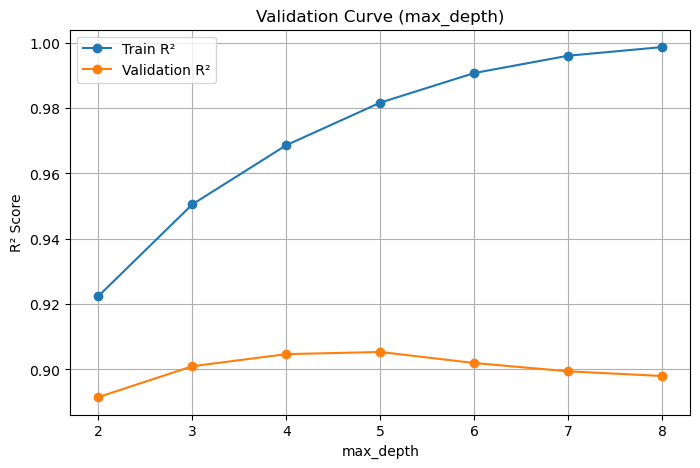

In [ ]:


# Define model (keep everything constant except max_depth)
model = XGBRegressor(
    n_estimators=900,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.6,
    random_state=42,
    reg_lambda =  1.5,
    reg_alpha = 1
)

param_range = [2, 3, 4, 5, 6, 7, 8]

train_scores, val_scores = validation_curve(
    model,
    X_train,
    y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

# Mean scores
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Plot
plt.figure(figsize=(8,5))
plt.plot(param_range, train_mean, label="Train R²", marker='o')
plt.plot(param_range, val_mean, label="Validation R²", marker='o')

plt.xlabel("max_depth")
plt.ylabel("R² Score")
plt.title("Validation Curve (max_depth)")
plt.legend()
plt.grid()
plt.show()

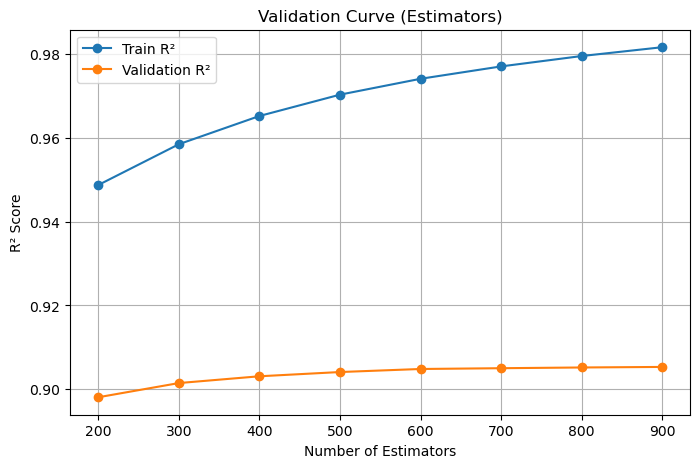

In [89]:

# Define model (keep everything constant except max_depth)
model = XGBRegressor(
    learning_rate=0.05,
    subsample= 0.8, 
    max_depth = 5,
    colsample_bytree=0.6,
    random_state=42,
    reg_lambda =  1.5,
    reg_alpha = 1
)

param_range = [200,300,400,500,600,700,800,900]

train_scores, val_scores = validation_curve(
    model,
    X_train,
    y_train,
    param_name="n_estimators",
    param_range=param_range,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

# Mean scores
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Plot
plt.figure(figsize=(8,5))
plt.plot(param_range, train_mean, label="Train R²", marker='o')
plt.plot(param_range, val_mean, label="Validation R²", marker='o')

plt.xlabel("Number of Estimators")
plt.ylabel("R² Score")
plt.title("Validation Curve (Estimators)")
plt.legend()
plt.grid()
plt.show()

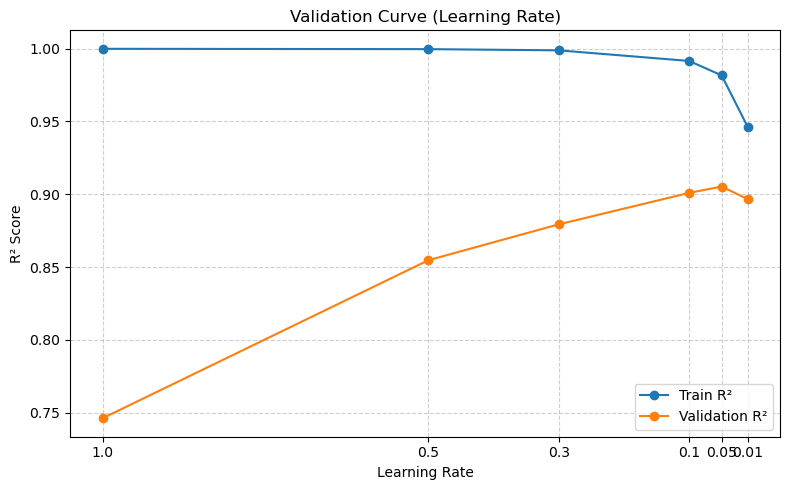

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve
from xgboost import XGBRegressor

# Model
model = XGBRegressor(
    n_estimators=900,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.6,
    reg_lambda=1.5,
    reg_alpha=1,
    random_state=42
)

# Learning rates (ascending for correct plotting)
param_range = np.array([0.01, 0.05, 0.1, 0.3, 0.5, 1])

# Validation curve
train_scores, val_scores = validation_curve(
    model,
    X_train,
    y_train,
    param_name="learning_rate",
    param_range=param_range,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

# Mean scores
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Plot
plt.figure(figsize=(8,5))

plt.plot(param_range, train_mean, marker='o', label="Train R²")
plt.plot(param_range, val_mean, marker='o', label="Validation R²")

# Reverse axis to show 1 → 0.01
plt.gca().invert_xaxis()

# Show exact tick values
plt.xticks(param_range, labels=[str(x) for x in param_range])

plt.xlabel("Learning Rate")
plt.ylabel("R² Score")
plt.title("Validation Curve (Learning Rate)")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()